# One-loop galaxy power spectrum: Eulerian PT (`EPT`)

In [1]:
import jax
import jax.numpy as jnp
import numpy as np

import matplotlib
import matplotlib.pyplot as plt

In [2]:
plt.rcParams['font.family'] ='sans-serif'
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.size'] = 6.0
plt.rcParams['ytick.major.size'] = 6.0
plt.rcParams['xtick.major.width'] = 1.0
plt.rcParams['ytick.major.width'] = 1.0
plt.rcParams['xtick.minor.size'] = 4.0
plt.rcParams['ytick.minor.size'] = 4.0
plt.rcParams['xtick.minor.width'] = 0.8
plt.rcParams['ytick.minor.width'] = 0.8
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['font.size'] = 16
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['text.usetex'] = False

In [3]:
import elf
import elf.params as ps_params

## Model setup

In [4]:
ept = elf.EPT()

## Parameters

The linear matter power spectrum is passed as an array of shape `(2, nk)`
stacking $k$ and $P_{\rm lin}(k)$.  The EFT parameters are grouped into

| group | entries |
|---|---|
| `bias`  | $b_1,\ b_2,\ b_{\mathcal{G}_2},\ b_{\Gamma_3}$ (Eulerian bias) |
| `ctr`   | $c_0,\ c_2,\ c_4,\ c_6,\ c_{44},\ c_{46},\ c_{48}$ |
| `stoch` | $P_{\rm shot},\ a_0,\ a_2$ |

In [5]:
## input linear matter power spectrum
d = np.loadtxt('data/pk_lin_planck18_fid_z0.txt')
pk_data = jnp.stack([d[:,0], d[:,1]], axis=0)

## other model parameters
f = 0.578
h = 0.6736
bias  = jnp.array([2.0, -0.5, -0.2, 0.5])       # b1, b2, bG2, bGamma3
ctr   = jnp.array([5.0, 10.0, -5.0, 0.0, 30.0, 20.0, -10.0])  # c0, c2, c4, c6, c44, c46, c48
stoch = jnp.array([1000.0, 0.0, 0.0])            # P_shot, a0, a2

params = ps_params.make_params(f=f, h=h, bias=bias, ctr=ctr, stoch=stoch)

## Redshift-space $P(k, \mu)$

In [6]:
## Output P(k,mu) as jax.numpy array of shape (len(k), len(mu))
k = jnp.linspace(1e-3, 0.3, 100)
mu = jnp.linspace(0.0, 1.0, 6)

ept.get_pkmu(k, mu, pk_data, params).block_until_ready()   # trigger JIT compilation
%time pkmu = ept.get_pkmu(k, mu, pk_data, params).block_until_ready()

CPU times: user 3.62 ms, sys: 800 μs, total: 4.42 ms
Wall time: 2.74 ms


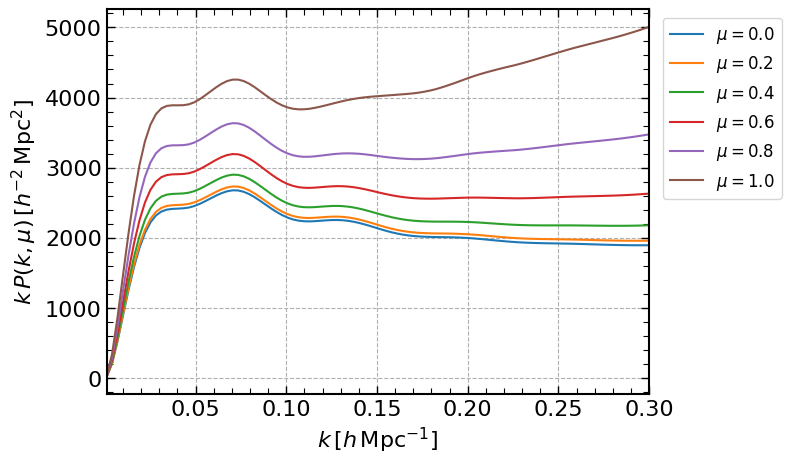

In [7]:
fig = plt.figure(figsize=(7,5))
color = plt.rcParams['axes.prop_cycle'].by_key()['color']
ax = fig.add_subplot()

for i, mu_i in enumerate(mu):
    ax.plot(k, k * pkmu[:,i], c=color[i], label=r'$\mu = {%.1f}$' % (mu_i))

plt.xlabel(r'$k \, [h \, \mathrm{Mpc}^{-1}]$')
plt.ylabel(r'$k \, P(k, \mu) \, [h^{-2} \, \mathrm{Mpc}^2]$')
plt.xlim(k.min(), k.max())
plt.legend(fontsize=12, bbox_to_anchor=(1.01, 1.0), loc='upper left')
plt.grid(linestyle='--')

## Redshift-space multipoles ($\ell = 0, 2, 4$ are supported)

In [8]:
ept.get_pk_ells(k, pk_data, params).block_until_ready()   # trigger JIT compilation
%time pkl = ept.get_pk_ells(k, pk_data, params).block_until_ready()

CPU times: user 3.2 ms, sys: 565 μs, total: 3.76 ms
Wall time: 2.14 ms


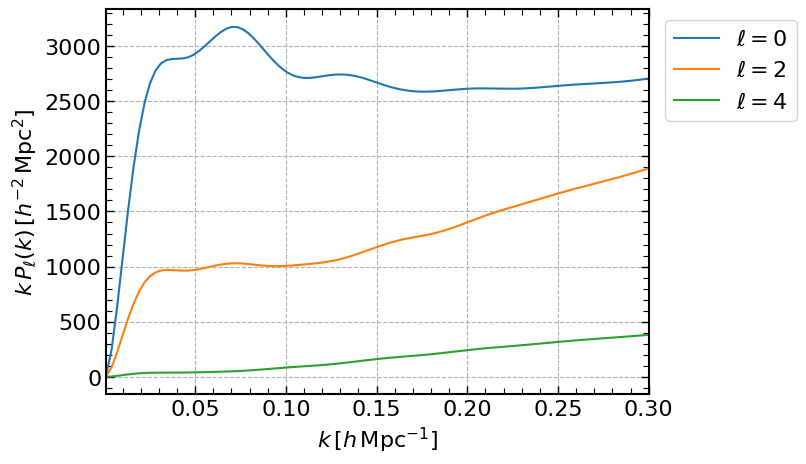

In [9]:
fig = plt.figure(figsize=(7,5))
ax = fig.add_subplot()

for i, l in enumerate([0,2,4]):
    ax.plot(k, k * pkl[i], label=r'$\ell = %s$' % (l))

plt.xlabel(r'$k \, [h \, \mathrm{Mpc}^{-1}]$')
plt.ylabel(r'$k \, P_{\ell}(k) \, [h^{-2} \, \mathrm{Mpc}^2]$')
plt.xlim(k.min(), k.max())
plt.legend(fontsize=16, bbox_to_anchor=(1.01, 1.0), loc='upper left')
plt.grid(linestyle='--')

## Alcock-Paczynski effect

In [10]:
# AP parameters, depending on the reference cosmology and redshift
alpha_perp = 1.01
alpha_para = 1.0

ept.get_pk_ells(k, pk_data, params, alpha_perp=alpha_perp, alpha_para=alpha_para).block_until_ready()
%time pkl_AP = ept.get_pk_ells(k, pk_data, params, alpha_perp=alpha_perp, alpha_para=alpha_para).block_until_ready()

CPU times: user 4.2 ms, sys: 1.51 ms, total: 5.71 ms
Wall time: 3.44 ms


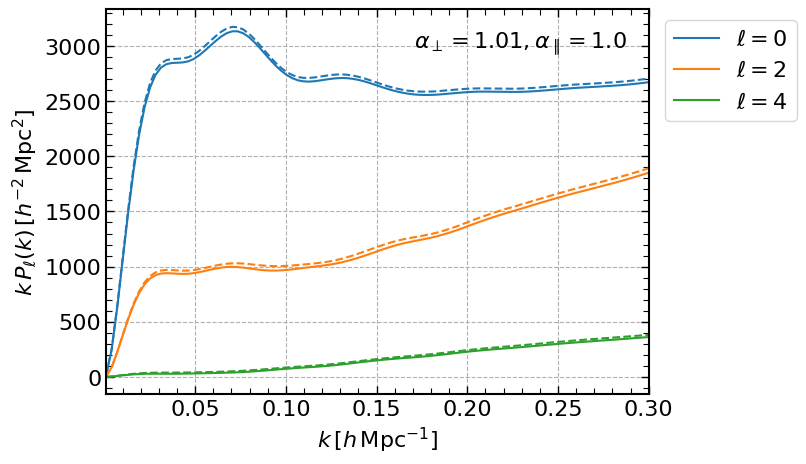

In [11]:
fig = plt.figure(figsize=(7,5))
color = plt.rcParams['axes.prop_cycle'].by_key()['color']
ax = fig.add_subplot()

for i, l in enumerate([0,2,4]):
    ax.plot(k, k * pkl_AP[i], c=color[i], label=r'$\ell = %s$' % (l))
    ax.plot(k, k * pkl[i], ls='--', c=color[i])

ax.text(0.96, 0.9, r'$\alpha_\perp=%s, \alpha_\parallel=%s$' % (alpha_perp, alpha_para),
        fontsize=16, transform=ax.transAxes, ha='right')

plt.xlabel(r'$k \, [h \, \mathrm{Mpc}^{-1}]$')
plt.ylabel(r'$k \, P_{\ell}(k) \, [h^{-2} \, \mathrm{Mpc}^2]$')
plt.xlim(k.min(), k.max())
plt.legend(fontsize=16, bbox_to_anchor=(1.01, 1.0), loc='upper left')
plt.grid(linestyle='--')

## Cross power spectrum of two tracers

`Params` takes an optional `bias2`.  With `bias2=None` (the default) you get the
auto spectrum; setting it gives the cross spectrum of the tracers with biases
`bias` and `bias2`.

`ctr` and `stoch` keep the same functional form as in the auto case and are
read as the cross spectrum's *own* coefficients: they are not derived from the
two auto spectra, so set them directly (e.g. zero cross shot noise for disjoint
samples).

In [12]:
params_a = params
params_b = ps_params.make_params(f=f, h=h, bias=jnp.array([1.4, -0.5, 0.05, -0.1]),
                                 ctr=ctr, stoch=stoch)              # second tracer's auto spectrum

# cross spectrum: bias2 = second tracer, ctr/stoch = the cross spectrum's own
params_ab = ps_params.make_params(f=f, h=h, bias=params_a.bias, bias2=params_b.bias,
                                  ctr=jnp.array([4.0, 8.0, -3.0, 0.0, 20.0, 15.0, -8.0]),
                                  stoch=jnp.array([0.0, 0.0, 0.0]))   # disjoint samples -> no cross shot noise

pkl_aa = ept.get_pk_ells(k, pk_data, params_a)
pkl_bb = ept.get_pk_ells(k, pk_data, params_b)
ept.get_pk_ells(k, pk_data, params_ab).block_until_ready()   # trigger JIT compilation
%time pkl_ab = ept.get_pk_ells(k, pk_data, params_ab).block_until_ready()

CPU times: user 3.6 ms, sys: 609 μs, total: 4.2 ms
Wall time: 2.47 ms


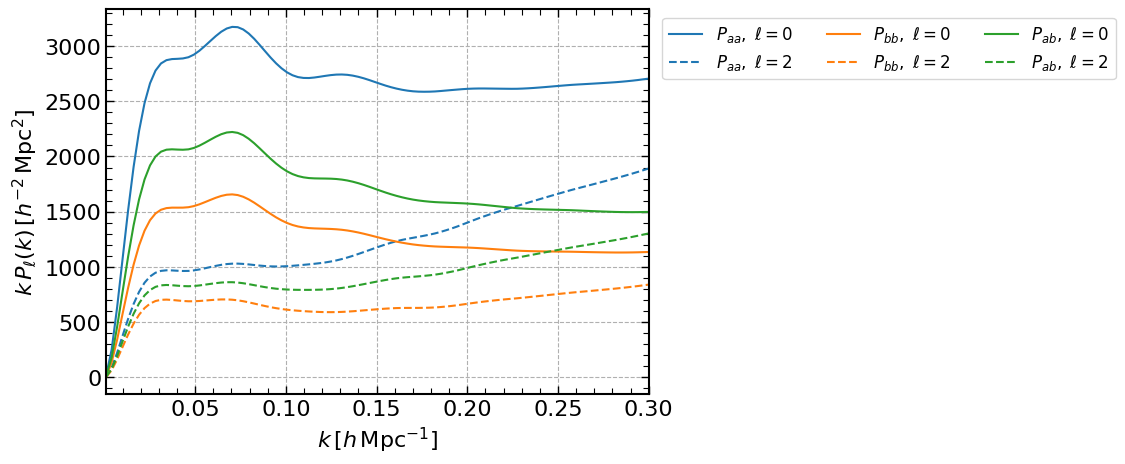

In [13]:
fig = plt.figure(figsize=(7,5))
color = plt.rcParams['axes.prop_cycle'].by_key()['color']
ax = fig.add_subplot()

for i, (lab, p) in enumerate([('$P_{aa}$', pkl_aa), ('$P_{bb}$', pkl_bb), ('$P_{ab}$', pkl_ab)]):
    ax.plot(k, k * p[0], c=color[i], label=lab + r'$,\ \ell=0$')
    ax.plot(k, k * p[1], c=color[i], ls='--', label=lab + r'$,\ \ell=2$')

plt.xlabel(r'$k \, [h \, \mathrm{Mpc}^{-1}]$')
plt.ylabel(r'$k \, P_{\ell}(k) \, [h^{-2} \, \mathrm{Mpc}^2]$')
plt.xlim(k.min(), k.max())
plt.legend(fontsize=12, ncol=3, bbox_to_anchor=(1.01, 1.0), loc='upper left')
plt.grid(linestyle='--')

In [14]:
# sanity checks: swapping the two tracers leaves the cross spectrum unchanged, and bias2 == bias reduces to the auto spectrum
params_ba = ps_params.make_params(f=f, h=h, bias=params_ab.bias2, bias2=params_ab.bias, ctr=params_ab.ctr, stoch=params_ab.stoch)
params_aa = ps_params.make_params(f=f, h=h, bias=params_a.bias, bias2=params_a.bias, ctr=params_a.ctr, stoch=params_a.stoch)
print('P_ab == P_ba :', np.allclose(pkl_ab, ept.get_pk_ells(k, pk_data, params_ba)))
print('P(bias2=bias) == P_auto :', np.allclose(pkl_aa, ept.get_pk_ells(k, pk_data, params_aa)))

P_ab == P_ba : True
P(bias2=bias) == P_auto : True
